In [2]:
using Distributions
using Random
using Plots  
using Optim
using LinearAlgebra

# Estimação

In [86]:
N = 80000

Random.seed!(126)

sigma2 = 30

x = rand(N, 1)
u = rand(Normal(0,sigma2 ), N)
y = rand(N, 1)

for i in 1:N 
    y[i] = 1 + exp( 2*x[i] ) + u[i]     # beta = [1,2]
end    

W = [1 0 ; 0 4 ]

function Q_NLS(n,β) 
     (1/n) *sum(   [ ( y[i] - β[1] - exp( β[2]*x[i] ) )^2  for i in 1:n ]     )  
end

function Q_GMM(n,β)  
    
    g1 = (1/n) *sum(   [ x[i]*( y[i] - β[1] - exp( β[2]*x[i] )  ) for i in 1:n ]     ) 
    g2 = (1/n) *sum(   [ x[i]*( y[i] - β[1] - exp( β[2]*x[i] )  )^2 for i in 1:n ]      ) - sigma2   
    
    return [g1 ; g2]' * W * [g1 ; g2]
end    

NLS = optimize(β -> Q_NLS(N, β), zeros(2))
GMM = optimize(β -> Q_GMM(N, β), zeros(2))

NLS = Optim.minimizer(NLS)
GMM = Optim.minimizer(GMM)

println(" NLS = $NLS")
println(" GMM = $GMM")


 NLS = [0.866970926742072, 1.9885312015594734]
 GMM = [0.7464091829223987, 2.019644550571546]


# Consistência

In [41]:
n_grid = 100 :1200: N

estim = zeros(N, 4)

for n in n_grid

   NLS = optimize(β -> Q_NLS(n, β), zeros(2))
   GMM = optimize(β -> Q_GMM(n, β), zeros(2))

   entry = findfirst(==(n), n_grid)

    
 estim[entry , 1] = Optim.minimizer(NLS)[1] 
 estim[entry , 2] = Optim.minimizer(NLS)[2]
 estim[entry , 3] = Optim.minimizer(GMM)[1]
 estim[entry , 4] = Optim.minimizer(GMM)[2] 
end  

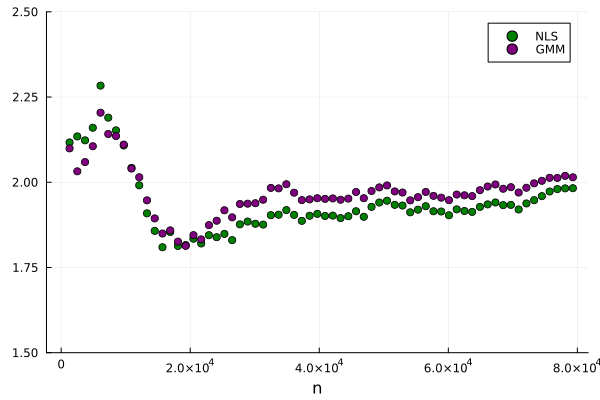

In [42]:
plot(n_grid, estim[:,2],
     seriestype = :scatter,
     label = "NLS",
     xlabel = "n",
     ylabel = "β2",
     color = :green,
     markersize = 4,
     ylims = (1.5, 2.5)) 


plot!(n_grid, estim[:,4],
     seriestype = :scatter,
     label = "GMM",
     xlabel = "n",
     ylabel = "",
     color = :purple,
     markersize = 4)      

# Normalidade Assintótica

In [ ]:
n_grid = [10, 20, 100 ]
M = 1000
betas = zeros(M, 4)

sigma2 = 1
a = sqrt(3)*sigma2

for n in n_grid
    for m in 1:M

        Random.seed!(m)

        x = rand(n, 1)
        u = rand(Uniform(-a, a), n)
        y = rand(n, 1)

        for i in 1:n
        y[i] = 1 + exp( x[i] ) + u[i]
        end 

        function Q_GMM(n,β)  
        
            g1 = (1/n) *sum(   [ x[i]*( y[i] - β[1] - exp( β[2]*x[i] )  ) for i in 1:n ]     ) 
            g2 = (1/n) *sum(   [ x[i]*( y[i] - β[1] - exp( β[2]*x[i] )  )^2 for i in 1:n ]      )    - sigma2
        
        return [g1 ; g2]' * W * [g1 ; g2]
        end 

        GMM = optimize(β -> Q_GMM(n, β), zeros(2))

        entry = findfirst(==(n), n_grid)
        
        betas[m,  entry] = Optim.minimizer(GMM)[2] 

        if m in 50:50:M println("n = $n, m = $m" ) end

    end    
end    


    

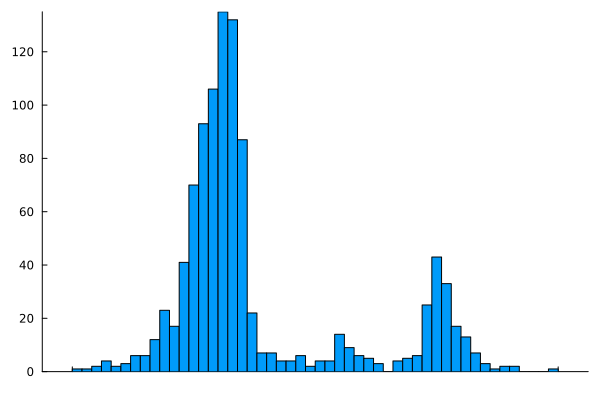

In [99]:
n = 10
j = 1
stats = [  sqrt(n) *( betas[m,j] - 2) for m in 1:M ]

histogram( stats, bins = 60 ,grid=false, legend = false,xtickfontcolor=:transparent) 

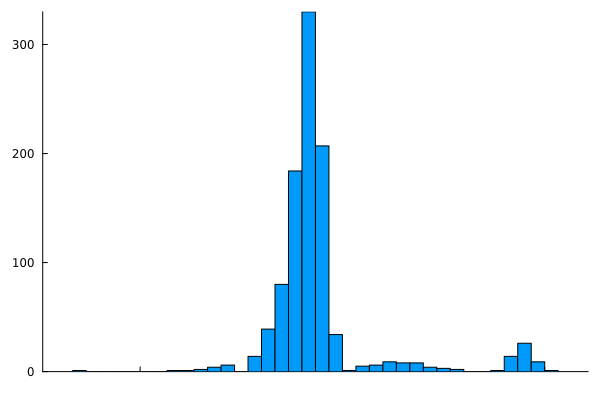

In [100]:
n = 20
j = 2
stats = [  sqrt(n) *( betas[m,j] - 2) for m in 1:M ]

histogram( stats, bins = 60, grid=false, legend = false, xtickfontcolor=:transparent )

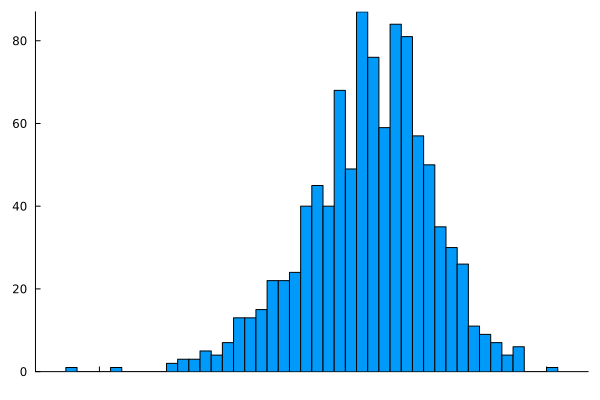

In [102]:
n = 100
j = 3
stats = [  sqrt(n) *( betas[m,j] - 2) for m in 1:M ]

histogram( stats, bins = 60,grid=false, legend = false,xtickfontcolor=:transparent )